# Omnis — FLUX.1-schnell on free Kaggle GPU

Renders the same prompts your local SD 1.5 gets wrong, on a model whose text
encoder actually binds attributes to objects.

**Set these in the right-hand panel before running:**

| Setting | Value |
|---|---|
| **Accelerator** | `GPU T4 x2` |
| **Internet** | `On` (needs phone verification on your account) |

T4 rather than P100: FLUX needs 4-bit quantisation to fit in 16 GB, and
bitsandbytes is far better supported on Turing (T4) than on Pascal (P100).

**Why FLUX and not SDXL or SD 1.5.** FLUX.1-schnell is 12B parameters and uses
a T5 text encoder. SD 1.5 uses CLIP, which treats a prompt as a bag of
concepts — ask it for a *yellow* danfo and you get a red bus, because nothing
binds "yellow" to "bus". T5 does that binding. It is the single reason FLUX
follows instructions and SD 1.5 does not.

**Licence:** FLUX.1-schnell is Apache 2.0 — commercial use is permitted, so it
can ship inside AfriKDP and Skilluxo. The repository is gated all the same,
so downloading needs an accepted licence and a token - see step 2; the
licence and the gate are separate things. FLUX.1-**dev** is gated *and*
non-commercial, so it cannot ship in a paid product at all. Do not swap
one for the other.

In [1]:
!nvidia-smi --query-gpu=name,memory.total --format=csv
import torch; print("torch", torch.__version__, "| cuda", torch.cuda.is_available())
assert torch.cuda.is_available(), "No GPU. Settings -> Accelerator -> GPU T4 x2"


name, memory.total [MiB]
Tesla T4, 15360 MiB
Tesla T4, 15360 MiB
torch 2.10.0+cu128 | cuda True


## 1. Install

`sentencepiece` and `protobuf` are not optional — FLUX's T5 tokenizer will not
load without them, and the failure message does not say so.

In [2]:
!pip install -q -U diffusers transformers accelerate safetensors     bitsandbytes sentencepiece protobuf
import diffusers, transformers, bitsandbytes
print("diffusers", diffusers.__version__, "| transformers", transformers.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.8/796.8 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.3/125.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 104.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is th

## 2. Authenticate with Hugging Face

FLUX.1-schnell is **Apache 2.0 licensed but the repository is gated** - Black
Forest Labs requires you to accept terms and authenticate before downloading.
The licence permits commercial use; the gate only controls the download.

Three one-time steps:

1. Open <https://huggingface.co/black-forest-labs/FLUX.1-schnell> while signed
   in, and click **Agree and access repository**. It is instant, no waiting.
2. Create a **read** token at <https://huggingface.co/settings/tokens>.
3. In this notebook: **Add-ons → Secrets → Add secret**, name it exactly
   `HF_TOKEN`, paste the token, and tick the checkbox to attach it.

Put the token in Kaggle Secrets, never in a cell. A notebook you share or make
public carries its source with it, and a pasted token would go with it.

In [3]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login, model_info

NO_SECRET = """No HF_TOKEN secret found.

  Add-ons -> Secrets -> Add secret, named exactly HF_TOKEN,
  then tick the checkbox so this notebook can read it.
"""

STILL_GATED = """Your token works, but the repo is still closed to you.

  Open https://huggingface.co/black-forest-labs/FLUX.1-schnell
  and click "Agree and access repository", then re-run this cell.
"""

try:
    HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
except Exception as e:
    raise SystemExit(f"{NO_SECRET}\n({type(e).__name__}: {e})")

login(token=HF_TOKEN)

# Check access with a cheap metadata call first. Without this the gate error
# arrives at the end of a 24 GB download instead of the start.
try:
    model_info("black-forest-labs/FLUX.1-schnell", token=HF_TOKEN)
    print("FLUX.1-schnell access confirmed")
except Exception as e:
    raise SystemExit(f"{STILL_GATED}\n({type(e).__name__}: {e})")


FLUX.1-schnell access confirmed


## 3. Load FLUX in 4-bit

FLUX is 12B parameters — about 24 GB in fp16, which does not fit in a 16 GB
T4. Quantising the transformer and the T5 encoder to NF4 brings it to roughly
8 GB with very little visible quality loss, and CPU offload keeps the peak
lower still.

First run downloads ~24 GB. On Kaggle that takes a few minutes; on your laptop
connection it would take a day, which is the other reason to do this here.

In [4]:
import torch
from diffusers import FluxPipeline, FluxTransformer2DModel
from diffusers import BitsAndBytesConfig as DiffusersBnb
from transformers import T5EncoderModel
from transformers import BitsAndBytesConfig as TransformersBnb

REPO = "black-forest-labs/FLUX.1-schnell"     # Apache 2.0, but gated: needs a token
DTYPE = torch.float16                          # T4 is Turing: no bf16

nf4_t = DiffusersBnb(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                     bnb_4bit_compute_dtype=DTYPE)
nf4_e = TransformersBnb(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                        bnb_4bit_compute_dtype=DTYPE)

transformer = FluxTransformer2DModel.from_pretrained(
    REPO, subfolder="transformer", quantization_config=nf4_t,
    torch_dtype=DTYPE, token=HF_TOKEN)
text_encoder_2 = T5EncoderModel.from_pretrained(
    REPO, subfolder="text_encoder_2", quantization_config=nf4_e,
    torch_dtype=DTYPE, token=HF_TOKEN)

pipe = FluxPipeline.from_pretrained(
    REPO, transformer=transformer, text_encoder_2=text_encoder_2,
    torch_dtype=DTYPE, token=HF_TOKEN)
pipe.enable_model_cpu_offload()
print("FLUX ready")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

(…)ion_pytorch_model.safetensors.index.json:   0%|          | 0.00/121k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

FLUX ready


## 4. The prompts SD 1.5 failed

These are the exact requests that came back wrong locally. Watch the colour of
the bus: SD 1.5 was told *yellow* and rendered red, because CLIP never bound
the adjective to the noun.

`schnell` is timestep-distilled, so it takes **4 steps** and
`guidance_scale=0.0`. Raising either does not improve it — the model was
trained not to need them.

In [5]:
PROMPTS = [
  ("danfo", "a yellow danfo minibus in Lagos traffic at golden hour, "
            "hand-painted lettering on the side, passengers leaning from the "
            "windows, documentary photograph, 35mm"),
  ("gele",  "studio portrait of a Nigerian woman in a coral aso-oke gele head "
            "wrap, soft window light, 85mm, sharp detail in the fabric weave"),
  ("kano",  "a Hausa Muslim wedding in Kano, northern Nigeria, bride in an "
            "embroidered veil with henna on her hands, warm afternoon light, "
            "editorial photograph"),
  ("cover", "illustrated book cover, a tortoise with a patterned shell on a "
            "red laterite path, baobab trees behind, warm dusk light, flat "
            "vector illustration, empty space at the top for a title"),
  ("egusi", "a bowl of egusi soup with pounded yam on a wooden table, "
            "overhead food photograph, natural window light"),
]

import os, time
os.makedirs("/kaggle/working/out", exist_ok=True)
results = []
for name, prompt in PROMPTS:
    t0 = time.time()
    img = pipe(prompt, num_inference_steps=4, guidance_scale=0.0,
               height=1024, width=1024,
               generator=torch.Generator("cpu").manual_seed(7)).images[0]
    p = f"/kaggle/working/out/{name}.png"
    img.save(p)
    results.append((name, prompt, p, time.time() - t0))
    print(f"{name:6} {time.time()-t0:5.1f}s  -> {p}")


  0%|          | 0/4 [00:00<?, ?it/s]

danfo   33.5s  -> /kaggle/working/out/danfo.png


  0%|          | 0/4 [00:00<?, ?it/s]

gele    30.8s  -> /kaggle/working/out/gele.png


  0%|          | 0/4 [00:00<?, ?it/s]

kano    31.2s  -> /kaggle/working/out/kano.png


  0%|          | 0/4 [00:00<?, ?it/s]

cover   32.3s  -> /kaggle/working/out/cover.png


  0%|          | 0/4 [00:00<?, ?it/s]

egusi   33.0s  -> /kaggle/working/out/egusi.png


## 5. Look at them

Judge two things separately, because they have different fixes.

**Did it follow the prompt?** Is the bus yellow, is the gele coral, is the
Kano wedding actually northern and Muslim rather than a white Western dress?
That is the base model, and it is what FLUX buys you.

**Is the cultural detail right?** A gele has a specific geometry; aso-oke has
a specific weave. FLUX will render something plausible and confident and quite
possibly wrong. That is what your dataset and a LoRA fix — no base model knows
it, because none of them were trained on enough of it.


=== danfo  (33.5s) ===
a yellow danfo minibus in Lagos traffic at golden hour, hand-painted lettering on the side, passengers leaning from the windows, documentary photograph, 35mm



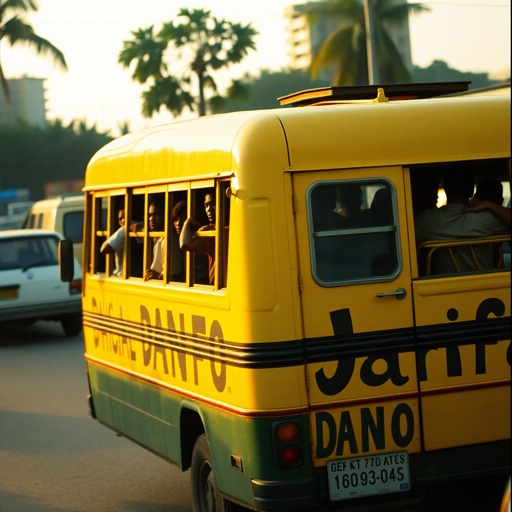


=== gele  (30.8s) ===
studio portrait of a Nigerian woman in a coral aso-oke gele head wrap, soft window light, 85mm, sharp detail in the fabric weave



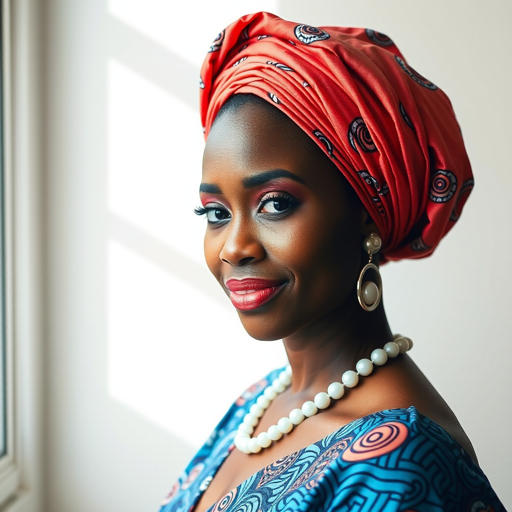


=== kano  (31.2s) ===
a Hausa Muslim wedding in Kano, northern Nigeria, bride in an embroidered veil with henna on her hands, warm afternoon light, editorial photograph



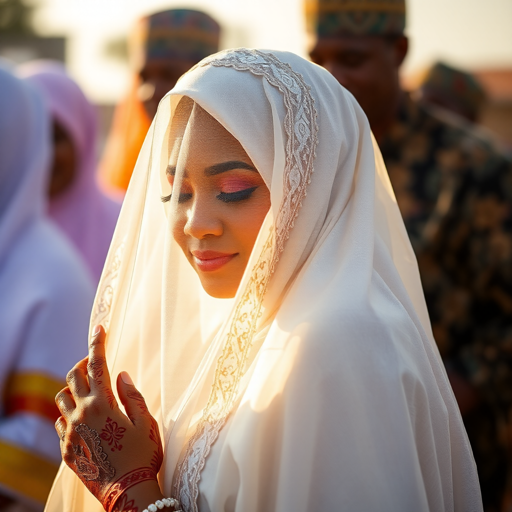


=== cover  (32.3s) ===
illustrated book cover, a tortoise with a patterned shell on a red laterite path, baobab trees behind, warm dusk light, flat vector illustration, empty space at the top for a title



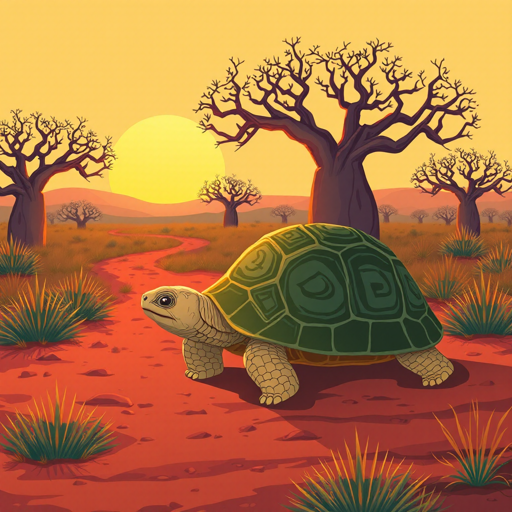


=== egusi  (33.0s) ===
a bowl of egusi soup with pounded yam on a wooden table, overhead food photograph, natural window light



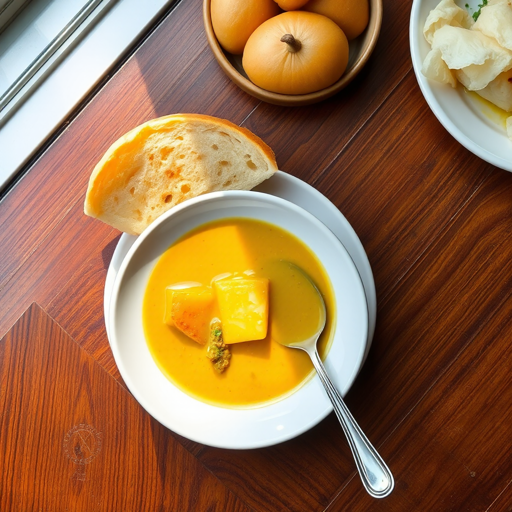

In [6]:
from IPython.display import display
from PIL import Image

for name, prompt, path, secs in results:
    print()
    print(f"=== {name}  ({secs:.1f}s) ===")
    print(prompt)
    print()
    display(Image.open(path).resize((512, 512)))


## 6. Keep them

Download from the **Output** tab on the right. These are also the first
reference images for judging whether a later LoRA actually improved anything —
keep them somewhere, because "it looks better now" is not measurable without a
before.

**Save Version → Save & Run All** runs this headless, so you can close the tab
and collect the output later rather than watching it.

### What this does not do

Kaggle's free tier can *run* FLUX but cannot *train* a FLUX LoRA — that needs
24 GB. Training the Nigerian adapter means renting a 24 GB card for a few
hours (~\$0.30/hr, so under \$10 for a full run). This notebook is how you
decide whether that is worth spending.

In [7]:
!ls -lh /kaggle/working/out

total 7.0M
-rw-r--r-- 1 root root 1.4M Sep  6 01:49 cover.png
-rw-r--r-- 1 root root 1.4M Sep  6 01:48 danfo.png
-rw-r--r-- 1 root root 1.8M Sep  6 01:50 egusi.png
-rw-r--r-- 1 root root 1.2M Sep  6 01:48 gele.png
-rw-r--r-- 1 root root 1.4M Sep  6 01:49 kano.png
